In [2]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:41847")
client

<Client: 'tcp://127.0.0.1:41847' processes=8 threads=48, memory=90.94 GiB>

In [3]:
import xarray as xr
import numpy as np
import os.path as op
import tripyview as tpv
import gsw
import matplotlib.pyplot as plt

# xr.set_options(keep_attrs=True)
# do_parallel       = True
# parallel_nprc     = 16   # number of dask workers
# parallel_nprc_bin = 8   # number of processor used to parallize the binning loop
# parallel_tmem     = 256   # max. available RAM

%matplotlib inline

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:8: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages


In [4]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
ddir = "/work/uo0119/a270067/runtime/awicm3-v3.1/"
sdir = "/scratch/b/b383315/"
wdir = "/work/ba1254/b383315/fesom2/next/"

In [6]:
NXX = 48
ds1 = xr.open_dataset(op.join(ddir,"N%2d/outdata/fesom/ke_adv_u.fesom.2000.nc"
                              % NXX),
                     chunks={"nz1":1,"x":100000}
                    )
ds = xr.open_dataset(op.join(ddir,"N%2d/outdata/fesom/w.fesom.2000.nc"
                             % NXX),
                     chunks={"nz":1,"x":100000}
                    )
ds1, ds

(<xarray.Dataset> Size: 29GB
 Dimensions:  (time: 12, nz1: 47, x: 12952215)
 Coordinates:
   * time     (time) datetime64[ns] 96B 2000-01-31T23:57:00 ... 2000-12-31T23:...
   * nz1      (nz1) float64 376B 2.5 7.5 15.0 ... 5.525e+03 5.825e+03 6.125e+03
 Dimensions without coordinates: x
 Data variables:
     unod     (time, nz1, x) float32 29GB dask.array<chunksize=(1, 1, 100000), meta=np.ndarray>
 Attributes: (12/21)
     CDI:                                 Climate Data Interface version 2.2.4...
     Conventions:                         CF-1.6
     FESOM_model:                         FESOM2
     FESOM_website:                       fesom.de
     FESOM_git_SHA:                       e23bc823
     FESOM_MeshPath:                      /work/ab0995/a270067/fesom2/next/mesh/
     ...                                  ...
     FESOM_evp_rheol_steps:               120
     FESOM_opt_visc:                      7
     FESOM_use_wsplit:                    -1
     FESOM_autorotate_back_to_geo: 

In [6]:
iz2000 = 31
iz4300 = 40
dz = xr.DataArray(np.diff(ds.nz), dims=["nz1"],
                  coords={"nz1":ds1.nz1}
                 ).isel(nz1=slice(None,iz4300))
dz

<xarray.DataArray (nz1: 40)> Size: 320B
array([  5.,   5.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,
        15.,  20.,  25.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100.,
       110., 120., 130., 140., 150., 170., 200., 220., 230., 250., 250.,
       250., 250., 250., 250., 250., 250., 250.])
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03

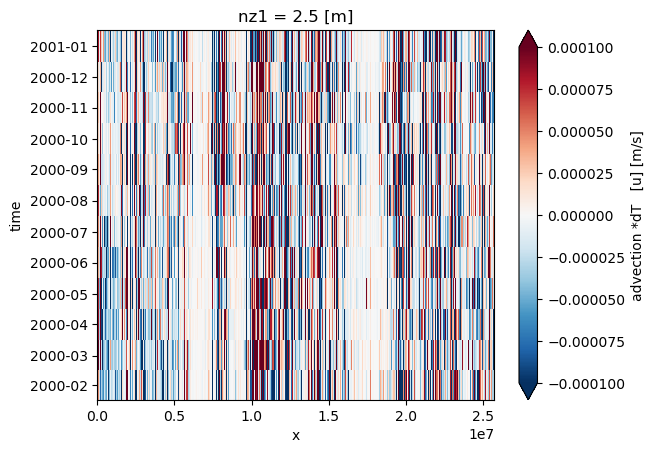

In [7]:
ds.ke_adv_u.isel(nz1=0).plot(vmax=1e-4, rasterized=True)

In [7]:
NXX = 48
nz = 47

plt_contb = True        # background contour line (thin)
plt_contf = False       # contour line of main colorbar steps 
plt_contr = False       # contour line of reference value 
plt_contl = False       # label contourline of main colorbar steps 
do_plt = 'tcf'          # plot pcolor (tpc) or contourf (tcf)
box = [-180, 180, -90, -30] # regional limitation of plot. [lonmin, lonmax, latmin, latmax]
# proj = 'rob'               # Robinson projection
proj = 'sps'               # SouthPolarStereo projection
do_rescale = None          # rescale data: None, 'log10', 'slog10', np.array(...)
nrow0 = 2                  # int, (default: 1) number of columns when plotting multiple data panels
ncol0 = 2                  # int, (default: 1) number of rows when plotting multiple data panels
do_enum = False            # bool, (default: False) do enumeration of axes with a), b), c) …
cbl_opt = dict()           # dict, (default: dict()) direct option for colorbar labels (fontsize, fontweight, …) via kwarg
cbtl_opt = dict()          # dict, (default: dict()) direct option for colorbar tick labels (fontsize, fontweight, …) via kwarg
save_dpi = 500

# cstr      = 'matplotlib.RdBu_r'
# cnum      = 30
# cref      = 0
crange    = None
cmin      = None
cmax      = None
cfac      = None
climit    = None
chist     = True
ctresh    = 0.995

In [8]:
dt = 180. # 3 minutes

mesh_path = '/work/ab0995/a270067/fesom2/next/mesh/'
mesh = tpv.load_mesh_fesom2(mesh_path, do_rot='None', focus=0, 
                            do_info=True, do_pickle=False
                           )
mesh

 > load mesh from *.out files: /work/ab0995/a270067/fesom2/next/mesh
 > load e_area from fesom.mesh.diag.nc
 > load n_area from fesom.mesh.diag.nc
 > compute lsmask
 > save *.shp to /home/b/b383315/meshcache_tripyview/mesh/tripyview_fesom2_mesh_pbnd.shp
 > augment lsmask
 > save *.shp to /home/b/b383315/meshcache_tripyview/mesh/tripyview_fesom2_mesh_focus=0.shp
___FESOM2 MESH INFO________________________
 > path            = /work/ab0995/a270067/fesom2/next/mesh
 > id              = mesh
 > do rot          = None
 > [al,be,ga]      = 50, 15, -90
 > do augmpbnd     = True
 > do cavity       = False
 > do lsmask       = True
 > do earea,eresol = True, False
 > do narea,nresol = True, False
___________________________________________
 > #node           = 12952215
 > #elem           = 25742475
 > #lvls           = 48
___________________________________________


___FESOM2 MESH INFO________________________
 > path            = /work/ab0995/a270067/fesom2/next/mesh
 > id              = mesh
 > do rot          = None
 > [al,be,ga]      = 50, 15, -90
 > do augmpbnd     = True
 > do cavity       = False
 > do lsmask       = True
 > do earea,eresol = True, False
 > do narea,nresol = True, False
___________________________________________
 > #node           = 12952215
 > #elem           = 25742475
 > #lvls           = 48
___________________________________________

In [9]:
au_path = op.join(ddir,'N%02d/outdata/fesom/ke_adv_u.fesom.2000.nc'
                  % NXX)
adv_u = tpv.load_data_fesom2(mesh, au_path, do_filename=True,
                          vname="ke_adv_u", do_info=False,
                          depth=[ds.nz1[0].values], year=2000, mon=1
                         ).chunk({'nod2':10000})
adv_u

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 98.20 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tz

 > do interpolation e2n


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


<xarray.Dataset> Size: 311MB
Dimensions:     (nod2: 12952215)
Coordinates:
    nzi         float64 8B 0.0
    nz1         float64 8B 2.5
    lon         (nod2) float32 52MB dask.array<chunksize=(10000,), meta=np.ndarray>
    lat         (nod2) float32 52MB dask.array<chunksize=(10000,), meta=np.ndarray>
    nodi        (nod2) int32 52MB dask.array<chunksize=(10000,), meta=np.ndarray>
    w_A         (nod2) float32 52MB dask.array<chunksize=(10000,), meta=np.ndarray>
Dimensions without coordinates: nod2
Data variables:
    n_ke_adv_u  (nod2) float64 104MB dask.array<chunksize=(10000,), meta=np.ndarray>
Attributes: (12/20)
    CDI:                           Climate Data Interface version 2.0.5 (http...
    Conventions:                   CF-1.6
    FESOM_model:                   FESOM2
    FESOM_website:                 fesom.de
    FESOM_git_SHA:                 e23bc823
    FESOM_MeshPath:                /work/ab0995/a270067/fesom2/next/mesh/
    ...                            ...
    FESOM_evp_rheol_steps:         120
    FESOM_opt_visc:                7
    FESOM_use_wsplit:              -1
    FESOM_autorotate_back_to_geo:  0
    history:                       Sun Aug 03 21:56:57 2025: cdo -b 4B copy k...
    CDO:                           Climate Data Operators version 2.0.5 (http...

{'cstr': 'matplotlib.RdBu_r', 'cnum': 41, 'cmin': -0.0004, 'cmax': 0.0004, 'cref': np.float64(0.0), 'chist': True, 'ctresh': 0.995, 'cnlab': 8, 'cmap': <matplotlib.colors.ListedColormap object at 0x7fff90321460>, 'clevel': array([-4.0e-04, -3.9e-04, -3.8e-04, -3.7e-04, -3.6e-04, -3.5e-04,
       -3.4e-04, -3.3e-04, -3.2e-04, -3.1e-04, -3.0e-04, -2.9e-04,
       -2.8e-04, -2.7e-04, -2.6e-04, -2.5e-04, -2.4e-04, -2.3e-04,
       -2.2e-04, -2.1e-04, -2.0e-04, -1.9e-04, -1.8e-04, -1.7e-04,
       -1.6e-04, -1.5e-04, -1.4e-04, -1.3e-04, -1.2e-04, -1.1e-04,
       -1.0e-04, -9.0e-05, -8.0e-05, -7.0e-05, -6.0e-05, -5.0e-05,
       -4.0e-05, -3.0e-05, -2.0e-05, -1.0e-05,  0.0e+00,  1.0e-05,
        2.0e-05,  3.0e-05,  4.0e-05,  5.0e-05,  6.0e-05,  7.0e-05,
        8.0e-05,  9.0e-05,  1.0e-04,  1.1e-04,  1.2e-04,  1.3e-04,
        1.4e-04,  1.5e-04,  1.6e-04,  1.7e-04,  1.8e-04,  1.9e-04,
        2.0e-04,  2.1e-04,  2.2e-04,  2.3e-04,  2.4e-04,  2.5e-04,
        2.6e-04,  2.7e-04,  2.8e-04,  2.

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


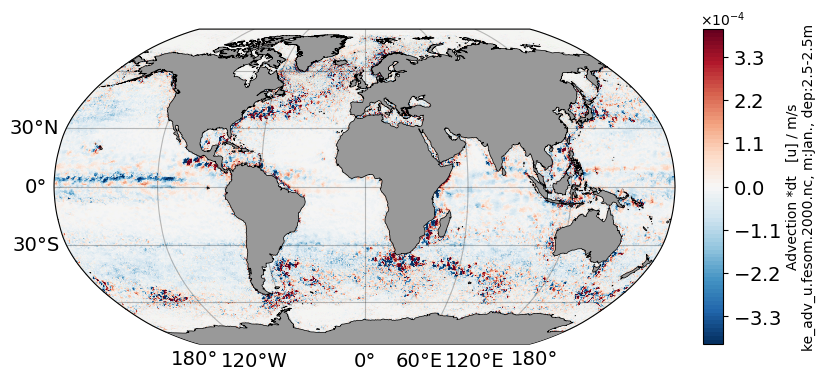

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [13]:
plt_contb = False        # background contour line (thin)
plt_contf = False       # contour line of main colorbar steps 
plt_contr = False       # contour line of reference value 
plt_contl = False       # label contourline of main colorbar steps 
do_plt = 'tpc'          # plot pcolor (tpc) or contourf (tcf)
box = [-180, 180, -90, 90] # regional limitation of plot. [lonmin, lonmax, latmin, latmax]
proj = 'rob'               # Robinson projection
# proj = 'sps'               # SouthPolarStereo projection
do_rescale = None          # rescale data: None, 'log10', 'slog10', np.array(...)
nrow0 = 1                  # int, (default: 1) number of columns when plotting multiple data panels
ncol0 = 1                  # int, (default: 1) number of rows when plotting multiple data panels
do_enum = False            # bool, (default: False) do enumeration of axes with a), b), c) …
cbl_opt = dict()           # dict, (default: dict()) direct option for colorbar labels (fontsize, fontweight, …) via kwarg
cbtl_opt = dict()          # dict, (default: dict()) direct option for colorbar tick labels (fontsize, fontweight, …) via kwarg
save_dpi = 500

# cstr      = 'matplotlib.RdBu_r'
# cnum      = 30
# cref      = 0
crange    = None
cmin      = None
cmax      = None
cfac      = None
climit    = None
chist     = True
ctresh    = 0.995

# cb_label = "DS05 - clim salt annual"
cstr      = 'matplotlib.RdBu_r'
# cstr      = 'cmocean.balance'
cnum      = 41
cref      = 0.
cmin      = -4e-4
cmax      = 4e-4


cinfo = tpv.set_cinfo(cstr, cnum, crange, cmin, cmax, 
                      cref, cfac, climit, chist, ctresh
                     )    
# save_path = op.join(wdir, '../../Figs/next/w_test.png')

hfig, hax, hcb = tpv.plot_hslice(
    mesh, 
    data=adv_u.load(), 
    cinfo=cinfo, 
    box=box, nrow=1, ncol=1, 
    proj=proj, do_rescale=do_rescale,  
    do_plt=do_plt, plt_contb=plt_contb, plt_contf=plt_contf, 
    plt_contr=plt_contr, plt_contl=plt_contl, 
    do_enum=do_enum, 
    axl_opt=dict({'fontsize':10, 'pad': 15}),
    ax_opt=dict({'fig_sizefac':2., 'cb_plt':True, 
                 'cb_plt_single':True, 'cb_pos':'vertical'}),
    cbl_opt=dict({'fontsize':10}), cb_label=None, 
    cbtl_opt=dict(),
    # do_save=save_path, 
    # save_dpi=save_dpi
)  

In [9]:
# px_path = op.join(ddir,'N%02d/outdata/fesom/ke_pre_u.fesom.2000.nc'
#                   % NXX)
# p_u = tpv.load_data_fesom2(mesh, px_path, do_filename=True,
#                           vname="ke_pre_u", do_info=False,
#                           depth=[ds.nz1[0].values], year=2000, mon=1
#                          ).chunk({'nod2':10000})
p_path = op.join(ddir,'N%02d/outdata/fesom/ke_PFULL.fesom.2000.nc'
                  % NXX)
dw_path = op.join(ddir,'N%02d/outdata/fesom/ke_dW.fesom.2000.nc'
                  % NXX)
for i in range(iz4300):
    if i == 0:
        p = tpv.load_data_fesom2(mesh, p_path, do_filename=True,
                                  vname="ke_PFULL", do_info=False,
                                  depth=[ds1.nz1[i].values], year=2000, mon=1
                                 ).chunk({'nod2':100000})
        dw = tpv.load_data_fesom2(mesh, dw_path, do_filename=True,
                                  vname="ke_dW", do_info=False,
                                  depth=[ds1.nz1[i].values], year=2000, mon=1
                                 ).chunk({'nod2':100000})
    else:
        p = xr.concat([p, 
                      tpv.load_data_fesom2(mesh, p_path, do_filename=True,
                              vname="ke_PFULL", do_info=False,
                              depth=[ds1.nz1[i].values], year=2000, mon=1
                             ).chunk({'nod2':100000})
                      ], "nz1")
        dw = xr.concat([dw, 
                      tpv.load_data_fesom2(mesh, dw_path, do_filename=True,
                              vname="ke_dW", do_info=False,
                              depth=[ds1.nz1[i].values], year=2000, mon=1
                             ).chunk({'nod2':100000})
                      ], "nz1")

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a fu

In [10]:
p, dw

(<xarray.Dataset> Size: 8GB
 Dimensions:   (nz1: 40, nod2: 12952215)
 Coordinates:
     nzi       (nz1) float64 320B 0.0 1.0 2.0 3.0 4.0 ... 36.0 37.0 38.0 39.0
     lon       (nod2) float32 52MB dask.array<chunksize=(100000,), meta=np.ndarray>
     lat       (nod2) float32 52MB dask.array<chunksize=(100000,), meta=np.ndarray>
     nodi      (nod2) int32 52MB dask.array<chunksize=(100000,), meta=np.ndarray>
     nodiz     (nod2) uint8 13MB dask.array<chunksize=(100000,), meta=np.ndarray>
     w_A       (nz1, nod2) float64 4GB dask.array<chunksize=(5, 100000), meta=np.ndarray>
   * nz1       (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
 Dimensions without coordinates: nod2
 Data variables:
     ke_PFULL  (nz1, nod2) float64 4GB dask.array<chunksize=(1, 100000), meta=np.ndarray>
 Attributes: (12/20)
     CDI:                           Climate Data Interface version 2.0.5 (http...
     Conventions:                   CF-1.6
     FESOM_model:                   FESOM2
  

In [11]:
pdw_path = op.join(ddir,'N%02d/outdata/fesom/W_x_RHO.fesom.2000.nc'
                  % NXX)
for i in range(iz4300):
    if i == 0:
        pdw = tpv.load_data_fesom2(mesh, pdw_path, do_filename=True,
                                  vname="ke_wrho", do_info=False,
                                  depth=[ds1.nz1[i].values], year=2000, mon=1
                                 ).chunk({'nod2':100000})
    else:
        pdw = xr.concat([pdw, 
                      tpv.load_data_fesom2(mesh, pdw_path, do_filename=True,
                              vname="ke_wrho", do_info=False,
                              depth=[ds1.nz1[i].values], year=2000, mon=1
                             ).chunk({'nod2':100000})
                      ], "nz1")

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a fu

In [12]:
pdw

<xarray.Dataset> Size: 8GB
Dimensions:  (nz1: 40, nod2: 12952215)
Coordinates:
    nzi      (nz1) float64 320B 0.0 1.0 2.0 3.0 4.0 ... 35.0 36.0 37.0 38.0 39.0
    lon      (nod2) float32 52MB dask.array<chunksize=(100000,), meta=np.ndarray>
    lat      (nod2) float32 52MB dask.array<chunksize=(100000,), meta=np.ndarray>
    nodi     (nod2) int32 52MB dask.array<chunksize=(100000,), meta=np.ndarray>
    nodiz    (nod2) uint8 13MB dask.array<chunksize=(100000,), meta=np.ndarray>
    w_A      (nz1, nod2) float64 4GB dask.array<chunksize=(5, 100000), meta=np.ndarray>
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
Dimensions without coordinates: nod2
Data variables:
    W_x_RHO  (nz1, nod2) float64 4GB dask.array<chunksize=(1, 100000), meta=np.ndarray>
Attributes: (12/21)
    CDI:                                 Climate Data Interface version 2.2.4...
    Conventions:                         CF-1.6
    FESOM_model:                         FESOM2
    FESOM_website:                       fesom.de
    FESOM_git_SHA:                       e23bc823
    FESOM_MeshPath:                      /work/ab0995/a270067/fesom2/next/mesh/
    ...                                  ...
    FESOM_evp_rheol_steps:               120
    FESOM_opt_visc:                      7
    FESOM_use_wsplit:                    -1
    FESOM_autorotate_back_to_geo:        0
    history:                             Fri Aug 01 20:52:01 2025: cdo cat W_...
    CDO:                                 Climate Data Operators version 2.2.2...

In [13]:
ppdwp = (pdw.W_x_RHO / dt 
         - (p.ke_PFULL * dw.ke_dW)
        ).to_dataset(name="Wp_x_RHOp")
ppdwp

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


<xarray.Dataset> Size: 8GB
Dimensions:    (nz1: 40, nod2: 12952215)
Coordinates:
    nzi        (nz1) float64 320B 0.0 1.0 2.0 3.0 4.0 ... 36.0 37.0 38.0 39.0
    lon        (nod2) float32 52MB dask.array<chunksize=(100000,), meta=np.ndarray>
    lat        (nod2) float32 52MB dask.array<chunksize=(100000,), meta=np.ndarray>
    nodi       (nod2) int32 52MB dask.array<chunksize=(100000,), meta=np.ndarray>
    nodiz      (nod2) uint8 13MB dask.array<chunksize=(100000,), meta=np.ndarray>
    w_A        (nz1, nod2) float64 4GB dask.array<chunksize=(5, 100000), meta=np.ndarray>
  * nz1        (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
Dimensions without coordinates: nod2
Data variables:
    Wp_x_RHOp  (nz1, nod2) float64 4GB dask.array<chunksize=(1, 100000), meta=np.ndarray>

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 791.60 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


{'cstr': 'matplotlib.RdBu_r', 'cnum': 41, 'cmin': -1e-06, 'cmax': 1e-06, 'cref': np.float64(0.0), 'chist': True, 'ctresh': 0.995, 'cnlab': 8, 'cmap': <matplotlib.colors.ListedColormap object at 0x7ff48e26c7d0>, 'clevel': array([-1.00e-06, -9.75e-07, -9.50e-07, -9.25e-07, -9.00e-07, -8.75e-07,
       -8.50e-07, -8.25e-07, -8.00e-07, -7.75e-07, -7.50e-07, -7.25e-07,
       -7.00e-07, -6.75e-07, -6.50e-07, -6.25e-07, -6.00e-07, -5.75e-07,
       -5.50e-07, -5.25e-07, -5.00e-07, -4.75e-07, -4.50e-07, -4.25e-07,
       -4.00e-07, -3.75e-07, -3.50e-07, -3.25e-07, -3.00e-07, -2.75e-07,
       -2.50e-07, -2.25e-07, -2.00e-07, -1.75e-07, -1.50e-07, -1.25e-07,
       -1.00e-07, -7.50e-08, -5.00e-08, -2.50e-08,  0.00e+00,  2.50e-08,
        5.00e-08,  7.50e-08,  1.00e-07,  1.25e-07,  1.50e-07,  1.75e-07,
        2.00e-07,  2.25e-07,  2.50e-07,  2.75e-07,  3.00e-07,  3.25e-07,
        3.50e-07,  3.75e-07,  4.00e-07,  4.25e-07,  4.50e-07,  4.75e-07,
        5.00e-07,  5.25e-07,  5.50e-07,  5.75e-07

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


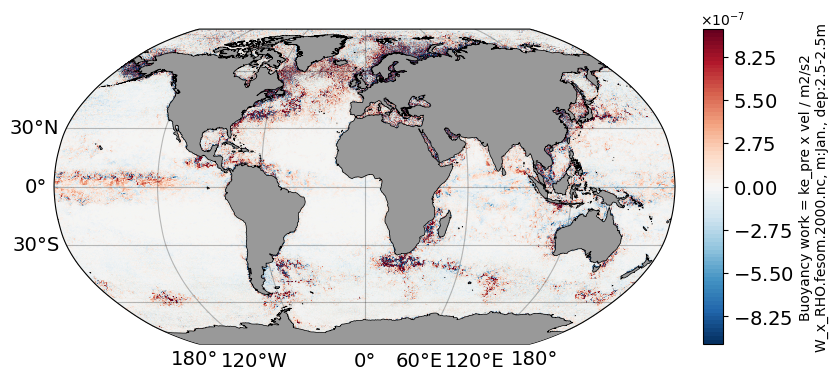

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [23]:
plt_contb = False        # background contour line (thin)
plt_contf = False       # contour line of main colorbar steps 
plt_contr = False       # contour line of reference value 
plt_contl = False       # label contourline of main colorbar steps 
do_plt = 'tpc'          # plot pcolor (tpc) or contourf (tcf)
box = [-180, 180, -90, 90] # regional limitation of plot. [lonmin, lonmax, latmin, latmax]
proj = 'rob'               # Robinson projection
# proj = 'sps'               # SouthPolarStereo projection
do_rescale = None          # rescale data: None, 'log10', 'slog10', np.array(...)
nrow0 = 1                  # int, (default: 1) number of columns when plotting multiple data panels
ncol0 = 1                  # int, (default: 1) number of rows when plotting multiple data panels
do_enum = False            # bool, (default: False) do enumeration of axes with a), b), c) …
cbl_opt = dict()           # dict, (default: dict()) direct option for colorbar labels (fontsize, fontweight, …) via kwarg
cbtl_opt = dict()          # dict, (default: dict()) direct option for colorbar tick labels (fontsize, fontweight, …) via kwarg
save_dpi = 500

# cstr      = 'matplotlib.RdBu_r'
# cnum      = 30
# cref      = 0
crange    = None
cfac      = None
climit    = None
chist     = True
ctresh    = 0.995

# cb_label = "DS05 - clim salt annual"
cstr      = 'matplotlib.RdBu_r'
# cstr      = 'cmocean.balance'
cnum      = 41
cref      = 0.
cmin      = -1e-6
cmax      = 1e-6


cinfo = tpv.set_cinfo(cstr, cnum, crange, cmin, cmax, 
                      cref, cfac, climit, chist, ctresh
                     )    
# save_path = op.join(wdir, '../../Figs/next/w_test.png')

hfig, hax, hcb = tpv.plot_hslice(
    mesh, 
    data=-ppdwp.isel(nz1=0).load(), 
    cinfo=cinfo, 
    box=box, nrow=1, ncol=1, 
    proj=proj, do_rescale=do_rescale,  
    do_plt=do_plt, plt_contb=plt_contb, plt_contf=plt_contf, 
    plt_contr=plt_contr, plt_contl=plt_contl, 
    do_enum=do_enum, 
    axl_opt=dict({'fontsize':10, 'pad': 15}),
    ax_opt=dict({'fig_sizefac':2., 'cb_plt':True, 
                 'cb_plt_single':True, 'cb_pos':'vertical'}),
    cbl_opt=dict({'fontsize':10}), cb_label=None, 
    cbtl_opt=dict(),
    # do_save=save_path, 
    # save_dpi=save_dpi
)  

In [14]:
h_path = op.join(ddir,'N%02d/outdata/fesom/MLD3.fesom.2000.nc'
                  % NXX)
mld = tpv.load_data_fesom2(mesh, h_path, do_filename=True,
                          vname="MLD3", do_info=False,
                          year=2000, mon=1
                         ).chunk({'nod2':100000})
mld

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


<xarray.Dataset> Size: 259MB
Dimensions:  (nod2: 12952215)
Coordinates:
    lon      (nod2) float32 52MB dask.array<chunksize=(100000,), meta=np.ndarray>
    lat      (nod2) float32 52MB dask.array<chunksize=(100000,), meta=np.ndarray>
    nodi     (nod2) int32 52MB dask.array<chunksize=(100000,), meta=np.ndarray>
    w_A      (nod2) float32 52MB dask.array<chunksize=(100000,), meta=np.ndarray>
Dimensions without coordinates: nod2
Data variables:
    MLD3     (nod2) float32 52MB dask.array<chunksize=(100000,), meta=np.ndarray>
Attributes: (12/21)
    CDI:                                 Climate Data Interface version 2.2.4...
    Conventions:                         CF-1.6
    FESOM_model:                         FESOM2
    FESOM_website:                       fesom.de
    FESOM_git_SHA:                       e23bc823
    FESOM_MeshPath:                      /work/ab0995/a270067/fesom2/next/mesh/
    ...                                  ...
    FESOM_evp_rheol_steps:               120
    FESOM_opt_visc:                      7
    FESOM_use_wsplit:                    -1
    FESOM_autorotate_back_to_geo:        0
    history:                             Fri Aug 01 20:31:57 2025: cdo cat ML...
    CDO:                                 Climate Data Operators version 2.2.2...

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 247.07 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


{'cstr': 'matplotlib.Blues_r', 'cnum': 41, 'cmin': -500, 'cmax': 0, 'chist': True, 'ctresh': 0.995, 'cnlab': 8, 'cref': np.float64(-200.0), 'cmap': <matplotlib.colors.ListedColormap object at 0x7ffdd45c9460>, 'clevel': array([-500., -490., -480., -470., -460., -450., -440., -430., -420.,
       -410., -400., -390., -380., -370., -360., -350., -340., -330.,
       -320., -310., -300., -290., -280., -270., -260., -250., -240.,
       -230., -220., -210., -200., -190., -180., -170., -160., -150.,
       -140., -130., -120., -110., -100.,  -90.,  -80.,  -70.,  -60.,
        -50.,  -40.,  -30.,  -20.,  -10.,    0.]), 'clab': array([-480., -410., -340., -270., -200., -130.,  -60.])}


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


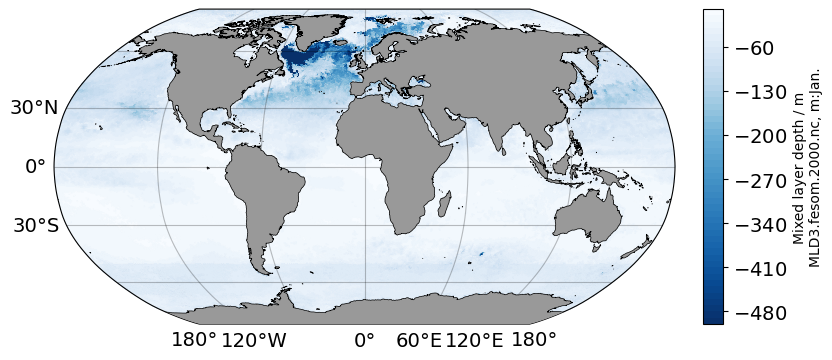

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [17]:
plt_contb = False        # background contour line (thin)
plt_contf = False       # contour line of main colorbar steps 
plt_contr = False       # contour line of reference value 
plt_contl = False       # label contourline of main colorbar steps 
do_plt = 'tpc'          # plot pcolor (tpc) or contourf (tcf)
box = [-180, 180, -90, 90] # regional limitation of plot. [lonmin, lonmax, latmin, latmax]
proj = 'rob'               # Robinson projection
# proj = 'sps'               # SouthPolarStereo projection
do_rescale = None          # rescale data: None, 'log10', 'slog10', np.array(...)
nrow0 = 1                  # int, (default: 1) number of columns when plotting multiple data panels
ncol0 = 1                  # int, (default: 1) number of rows when plotting multiple data panels
do_enum = False            # bool, (default: False) do enumeration of axes with a), b), c) …
cbl_opt = dict()           # dict, (default: dict()) direct option for colorbar labels (fontsize, fontweight, …) via kwarg
cbtl_opt = dict()          # dict, (default: dict()) direct option for colorbar tick labels (fontsize, fontweight, …) via kwarg
save_dpi = 500

# cstr      = 'matplotlib.RdBu_r'
# cnum      = 30
# cref      = 0
crange    = None
cfac      = None
climit    = None
chist     = True
ctresh    = 0.995

# cb_label = "DS05 - clim salt annual"
cstr      = 'matplotlib.Blues_r'
# cstr      = 'cmocean.balance'
cnum      = 41
cref      = None
cmin      = -500
cmax      = 0


cinfo = tpv.set_cinfo(cstr, cnum, crange, cmin, cmax, 
                      cref, cfac, climit, chist, ctresh
                     )    
# save_path = op.join(wdir, '../../Figs/next/w_test.png')

hfig, hax, hcb = tpv.plot_hslice(
    mesh, 
    data=mld.load(), 
    cinfo=cinfo, 
    box=box, nrow=1, ncol=1, 
    proj=proj, do_rescale=do_rescale,  
    do_plt=do_plt, plt_contb=plt_contb, plt_contf=plt_contf, 
    plt_contr=plt_contr, plt_contl=plt_contl, 
    do_enum=do_enum, 
    axl_opt=dict({'fontsize':10, 'pad': 15}),
    ax_opt=dict({'fig_sizefac':2., 'cb_plt':True, 
                 'cb_plt_single':True, 'cb_pos':'vertical'}),
    cbl_opt=dict({'fontsize':10}), cb_label=None, 
    cbtl_opt=dict(),
    # do_save=save_path, 
    # save_dpi=save_dpi
)  

In [15]:
ppdwpH = ((ppdwp.Wp_x_RHOp
           * dz
          ).where(ppdwp.nz1<np.abs(mld.MLD3)).sum("nz1",skipna=True) 
          / np.abs(mld.MLD3)
         ).to_dataset(name="WpRHOpH")
ppdwpH

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 3.87 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 4.39 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly


<xarray.Dataset> Size: 324MB
Dimensions:  (nod2: 12952215)
Coordinates:
    lon      (nod2) float32 52MB dask.array<chunksize=(100000,), meta=np.ndarray>
    lat      (nod2) float32 52MB dask.array<chunksize=(100000,), meta=np.ndarray>
    nodi     (nod2) int32 52MB dask.array<chunksize=(100000,), meta=np.ndarray>
    nodiz    (nod2) uint8 13MB dask.array<chunksize=(100000,), meta=np.ndarray>
    w_A      (nod2) float32 52MB dask.array<chunksize=(100000,), meta=np.ndarray>
Dimensions without coordinates: nod2
Data variables:
    WpRHOpH  (nod2) float64 104MB dask.array<chunksize=(100000,), meta=np.ndarray>

{'cstr': 'matplotlib.RdBu_r', 'cnum': 41, 'cmin': -1e-07, 'cmax': 1e-07, 'cref': np.float64(0.0), 'chist': True, 'ctresh': 0.995, 'cnlab': 8, 'cmap': <matplotlib.colors.ListedColormap object at 0x7ff5743de1b0>, 'clevel': array([-1.00e-07, -9.75e-08, -9.50e-08, -9.25e-08, -9.00e-08, -8.75e-08,
       -8.50e-08, -8.25e-08, -8.00e-08, -7.75e-08, -7.50e-08, -7.25e-08,
       -7.00e-08, -6.75e-08, -6.50e-08, -6.25e-08, -6.00e-08, -5.75e-08,
       -5.50e-08, -5.25e-08, -5.00e-08, -4.75e-08, -4.50e-08, -4.25e-08,
       -4.00e-08, -3.75e-08, -3.50e-08, -3.25e-08, -3.00e-08, -2.75e-08,
       -2.50e-08, -2.25e-08, -2.00e-08, -1.75e-08, -1.50e-08, -1.25e-08,
       -1.00e-08, -7.50e-09, -5.00e-09, -2.50e-09,  0.00e+00,  2.50e-09,
        5.00e-09,  7.50e-09,  1.00e-08,  1.25e-08,  1.50e-08,  1.75e-08,
        2.00e-08,  2.25e-08,  2.50e-08,  2.75e-08,  3.00e-08,  3.25e-08,
        3.50e-08,  3.75e-08,  4.00e-08,  4.25e-08,  4.50e-08,  4.75e-08,
        5.00e-08,  5.25e-08,  5.50e-08,  5.75e-08

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


 > save figure: /work/ba1254/b383315/fesom2/next/../../Figs/next/wb_test.png


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


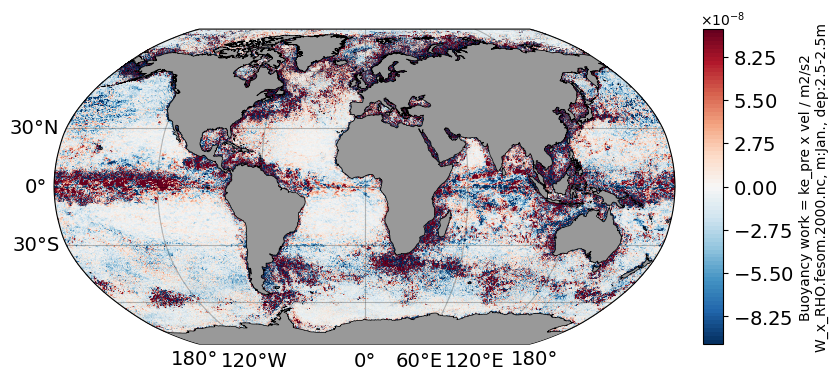

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [23]:
plt_contb = False        # background contour line (thin)
plt_contf = False       # contour line of main colorbar steps 
plt_contr = False       # contour line of reference value 
plt_contl = False       # label contourline of main colorbar steps 
do_plt = 'tpc'          # plot pcolor (tpc) or contourf (tcf)
box = [-180, 180, -90, 90] # regional limitation of plot. [lonmin, lonmax, latmin, latmax]
proj = 'rob'               # Robinson projection
# proj = 'sps'               # SouthPolarStereo projection
do_rescale = None          # rescale data: None, 'log10', 'slog10', np.array(...)
nrow0 = 1                  # int, (default: 1) number of columns when plotting multiple data panels
ncol0 = 1                  # int, (default: 1) number of rows when plotting multiple data panels
do_enum = False            # bool, (default: False) do enumeration of axes with a), b), c) …
cbl_opt = dict()           # dict, (default: dict()) direct option for colorbar labels (fontsize, fontweight, …) via kwarg
cbtl_opt = dict()          # dict, (default: dict()) direct option for colorbar tick labels (fontsize, fontweight, …) via kwarg
save_dpi = 500

# cstr      = 'matplotlib.RdBu_r'
# cnum      = 30
# cref      = 0
crange    = None
cfac      = None
climit    = None
chist     = True
ctresh    = 0.995

# cb_label = "DS05 - clim salt annual"
cstr      = 'matplotlib.RdBu_r'
# cstr      = 'cmocean.balance'
cnum      = 41
cref      = 0.
cmin      = -1e-7
cmax      = 1e-7


cinfo = tpv.set_cinfo(cstr, cnum, crange, cmin, cmax, 
                      cref, cfac, climit, chist, ctresh
                     )    
save_path = op.join(wdir, '../../Figs/next/wb_test.png')

hfig, hax, hcb = tpv.plot_hslice(
    mesh, 
    data=-ppdwpH.load(), 
    cinfo=cinfo, 
    box=box, nrow=1, ncol=1, 
    proj=proj, do_rescale=do_rescale,  
    do_plt=do_plt, plt_contb=plt_contb, plt_contf=plt_contf, 
    plt_contr=plt_contr, plt_contl=plt_contl, 
    do_enum=do_enum, 
    axl_opt=dict({'fontsize':10, 'pad': 15}),
    ax_opt=dict({'fig_sizefac':2., 'cb_plt':True, 
                 'cb_plt_single':True, 'cb_pos':'vertical'}),
    cbl_opt=dict({'fontsize':10}), cb_label=None, 
    cbtl_opt=dict(),
    do_save=save_path, 
    save_dpi=save_dpi
)  

In [15]:
# ppdwpH.to_zarr(op.join(wdir,"ppdwp_%4d-%02d.zarr" % (2000,1)),
#                mode='w')
# ppdwpH.close()
ppdwpH = xr.open_zarr(op.join(wdir,"ppdwp_%4d-%02d.zarr" % (2000,1)))
ppdwpH

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


<xarray.Dataset> Size: 324MB
Dimensions:  (nod2: 12952215)
Coordinates:
    nodiz    (nod2) uint8 13MB dask.array<chunksize=(809514,), meta=np.ndarray>
    w_A      (nod2) float32 52MB dask.array<chunksize=(202379,), meta=np.ndarray>
    lat      (nod2) float32 52MB dask.array<chunksize=(202379,), meta=np.ndarray>
    nodi     (nod2) int32 52MB dask.array<chunksize=(202379,), meta=np.ndarray>
    lon      (nod2) float32 52MB dask.array<chunksize=(202379,), meta=np.ndarray>
Dimensions without coordinates: nod2
Data variables:
    WpRHOpH  (nod2) float64 104MB dask.array<chunksize=(101190,), meta=np.ndarray>

In [16]:
w_path = op.join(ddir,'N%02d/outdata/fesom/w.fesom.2000.nc'
                  % NXX)
for i in range(iz4300+1):
    if i == 0:
        w = tpv.load_data_fesom2(mesh, w_path, do_filename=True,
                                  vname="w", do_info=False,
                                  depth=[ds.nz[i].values], year=2000, mon=1
                                 ).chunk({'nod2':100000}).w
    else:
        w = xr.concat([w, 
                      tpv.load_data_fesom2(mesh, w_path, do_filename=True,
                              vname="w", do_info=False,
                              depth=[ds.nz[i].values], year=2000, mon=1
                             ).chunk({'nod2':100000}).w
                      ], "nz")
w1 = xr.DataArray(.5*(w.isel(nz=slice(None,-1)).data
                      + w.isel(nz=slice(1,None)).data
                     ), 
                 dims=p.ke_PFULL.dims, coords=p.ke_PFULL.coords
                )

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a fu

In [17]:
w1

<xarray.DataArray 'mul-be56942a38d08c1411313c5d1c034af1' (nz1: 40,
                                                          nod2: 12952215)> Size: 4GB
dask.array<mul, shape=(40, 12952215), dtype=float64, chunksize=(1, 100000), chunktype=numpy.ndarray>
Coordinates:
    nzi      (nz1) float64 320B 0.0 1.0 2.0 3.0 4.0 ... 35.0 36.0 37.0 38.0 39.0
    lon      (nod2) float32 52MB dask.array<chunksize=(100000,), meta=np.ndarray>
    lat      (nod2) float32 52MB dask.array<chunksize=(100000,), meta=np.ndarray>
    nodi     (nod2) int32 52MB dask.array<chunksize=(100000,), meta=np.ndarray>
    nodiz    (nod2) uint8 13MB dask.array<chunksize=(100000,), meta=np.ndarray>
    w_A      (nz1, nod2) float64 4GB dask.array<chunksize=(5, 100000), meta=np.ndarray>
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
Dimensions without coordinates: nod2

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 247.24 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


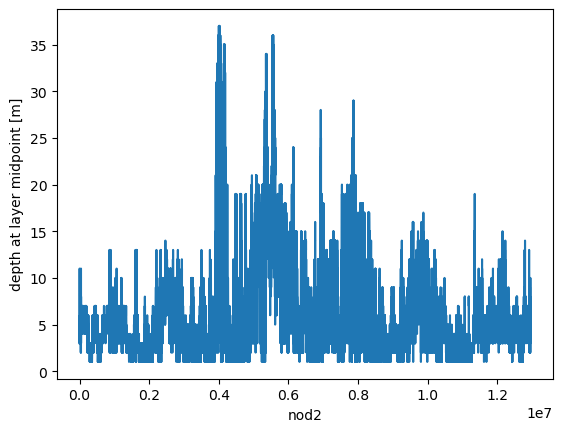

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 247.24 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


<xarray.Dataset> Size: 583MB
Dimensions:  (nod2: 12952215)
Coordinates:
    nzi      (nod2) float64 104MB 3.0 10.0 5.0 5.0 5.0 ... 5.0 4.0 5.0 4.0 4.0
    lon      (nod2) float32 52MB dask.array<chunksize=(100000,), meta=np.ndarray>
    lat      (nod2) float32 52MB dask.array<chunksize=(100000,), meta=np.ndarray>
    nodi     (nod2) int32 52MB dask.array<chunksize=(100000,), meta=np.ndarray>
    nodiz    (nod2) uint8 13MB dask.array<chunksize=(100000,), meta=np.ndarray>
    w_A      (nod2) float64 104MB dask.array<chunksize=(500000,), meta=np.ndarray>
    nz1      (nod2) float64 104MB 25.0 95.0 45.0 45.0 ... 35.0 45.0 35.0 35.0
Dimensions without coordinates: nod2
Data variables:
    wbpb     (nod2) float64 104MB dask.array<chunksize=(100000,), meta=np.ndarray>

In [20]:
iH = (np.abs(ds1.nz1 + mld.MLD3)).argmin("nz1")
iH.plot(rasterized=True)
plt.show()
pw = (p.ke_PFULL*w1).isel(nz1=iH.compute()).to_dataset(name="wbpb")
pw

In [21]:
pw.to_zarr(op.join(wdir,"pbwb_%4d-%02d.zarr" % (2000,1)),
           mode='w')
pw.close()
pw = xr.open_zarr(op.join(wdir,"pbwb_%4d-%02d.zarr" % (2000,1)))

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 4.30 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-prac

{'cstr': 'matplotlib.RdBu_r', 'cnum': 41, 'cmin': -1e-06, 'cmax': 1e-06, 'cref': np.float64(0.0), 'chist': True, 'ctresh': 0.995, 'cnlab': 8, 'cmap': <matplotlib.colors.ListedColormap object at 0x7ff574492840>, 'clevel': array([-1.00e-06, -9.75e-07, -9.50e-07, -9.25e-07, -9.00e-07, -8.75e-07,
       -8.50e-07, -8.25e-07, -8.00e-07, -7.75e-07, -7.50e-07, -7.25e-07,
       -7.00e-07, -6.75e-07, -6.50e-07, -6.25e-07, -6.00e-07, -5.75e-07,
       -5.50e-07, -5.25e-07, -5.00e-07, -4.75e-07, -4.50e-07, -4.25e-07,
       -4.00e-07, -3.75e-07, -3.50e-07, -3.25e-07, -3.00e-07, -2.75e-07,
       -2.50e-07, -2.25e-07, -2.00e-07, -1.75e-07, -1.50e-07, -1.25e-07,
       -1.00e-07, -7.50e-08, -5.00e-08, -2.50e-08,  0.00e+00,  2.50e-08,
        5.00e-08,  7.50e-08,  1.00e-07,  1.25e-07,  1.50e-07,  1.75e-07,
        2.00e-07,  2.25e-07,  2.50e-07,  2.75e-07,  3.00e-07,  3.25e-07,
        3.50e-07,  3.75e-07,  4.00e-07,  4.25e-07,  4.50e-07,  4.75e-07,
        5.00e-07,  5.25e-07,  5.50e-07,  5.75e-07

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


 > save figure: /work/ba1254/b383315/fesom2/next/../../Figs/next/wbpb_test.png


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


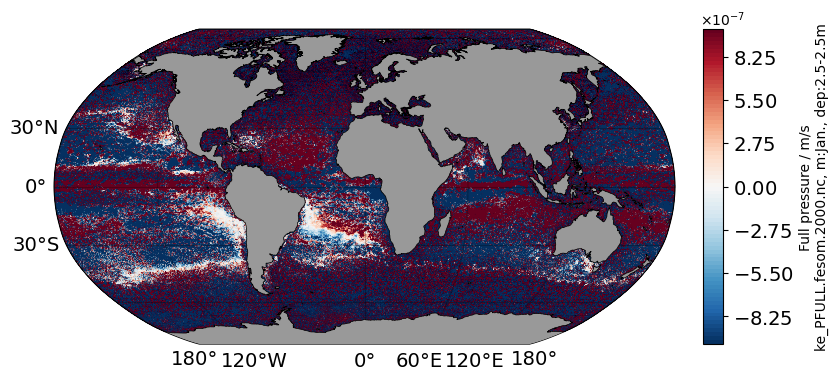

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [25]:
plt_contb = False        # background contour line (thin)
plt_contf = False       # contour line of main colorbar steps 
plt_contr = False       # contour line of reference value 
plt_contl = False       # label contourline of main colorbar steps 
do_plt = 'tpc'          # plot pcolor (tpc) or contourf (tcf)
box = [-180, 180, -90, 90] # regional limitation of plot. [lonmin, lonmax, latmin, latmax]
proj = 'rob'               # Robinson projection
# proj = 'sps'               # SouthPolarStereo projection
do_rescale = None          # rescale data: None, 'log10', 'slog10', np.array(...)
nrow0 = 1                  # int, (default: 1) number of columns when plotting multiple data panels
ncol0 = 1                  # int, (default: 1) number of rows when plotting multiple data panels
do_enum = False            # bool, (default: False) do enumeration of axes with a), b), c) …
cbl_opt = dict()           # dict, (default: dict()) direct option for colorbar labels (fontsize, fontweight, …) via kwarg
cbtl_opt = dict()          # dict, (default: dict()) direct option for colorbar tick labels (fontsize, fontweight, …) via kwarg
save_dpi = 500

# cstr      = 'matplotlib.RdBu_r'
# cnum      = 30
# cref      = 0
crange    = None
cfac      = None
climit    = None
chist     = True
ctresh    = 0.995

# cb_label = "DS05 - clim salt annual"
cstr      = 'matplotlib.RdBu_r'
# cstr      = 'cmocean.balance'
cnum      = 41
cref      = 0.
cmin      = -1e-6
cmax      = 1e-6


cinfo = tpv.set_cinfo(cstr, cnum, crange, cmin, cmax, 
                      cref, cfac, climit, chist, ctresh
                     )    
save_path = op.join(wdir, '../../Figs/next/wbpb_test.png')

hfig, hax, hcb = tpv.plot_hslice(
    mesh, 
    data=pw.load(), 
    cinfo=cinfo, 
    box=box, nrow=1, ncol=1, 
    proj=proj, do_rescale=do_rescale,  
    do_plt=do_plt, plt_contb=plt_contb, plt_contf=plt_contf, 
    plt_contr=plt_contr, plt_contl=plt_contl, 
    do_enum=do_enum, 
    axl_opt=dict({'fontsize':10, 'pad': 15}),
    ax_opt=dict({'fig_sizefac':2., 'cb_plt':True, 
                 'cb_plt_single':True, 'cb_pos':'vertical'}),
    cbl_opt=dict({'fontsize':10}), cb_label=None, 
    cbtl_opt=dict(),
    do_save=save_path, 
    save_dpi=save_dpi
)  

In [ ]:
ystart = 2000
NXX = 48

for yy in range(ystart,2011):
    
    p_path = op.join(ddir,'N%02d/outdata/fesom/ke_PFULL.fesom.%4d.nc'
                      % (NXX,yy))
    dw_path = op.join(ddir,'N%02d/outdata/fesom/ke_dW.fesom.%4d.nc'
                      % (NXX,yy))
    pdw_path = op.join(ddir,'N%02d/outdata/fesom/W_x_RHO.fesom.%4d.nc'
                      % (NXX,yy))
    h_path = op.join(ddir,'N%02d/outdata/fesom/MLD3.fesom.%4d.nc'
                      % (NXX,yy))
        
    if yy == ystart:
        months = range(6,13)
    else:
        months = range(1,13)
    
    for mm in months:
        mld = tpv.load_data_fesom2(mesh, h_path, do_filename=True,
                                  vname="MLD3", do_info=False,
                                  year=yy, mon=mm
                                 ).chunk({'nod2':100000})
        for i in range(iz4300):
            if i == 0:
                p = tpv.load_data_fesom2(mesh, p_path, do_filename=True,
                                          vname="ke_PFULL", do_info=False,
                                          depth=[ds1.nz1[i].values], 
                                         year=yy, mon=mm
                                         ).chunk({'nod2':100000})
                dw = tpv.load_data_fesom2(mesh, dw_path, do_filename=True,
                                          vname="ke_dW", do_info=False,
                                          depth=[ds1.nz1[i].values], 
                                          year=yy, mon=mm
                                         ).chunk({'nod2':100000})
                pdw = tpv.load_data_fesom2(mesh, pdw_path, do_filename=True,
                                          vname="ke_wrho", do_info=False,
                                          depth=[ds1.nz1[i].values], 
                                           year=yy, mon=mm
                                         ).chunk({'nod2':100000})
            else:
                p = xr.concat([p, 
                              tpv.load_data_fesom2(mesh, p_path, do_filename=True,
                                                  vname="ke_PFULL", do_info=False,
                                                  depth=[ds1.nz1[i].values], 
                                                   year=yy, mon=mm
                                     ).chunk({'nod2':100000})
                              ], "nz1")
                dw = xr.concat([dw, 
                              tpv.load_data_fesom2(mesh, dw_path, do_filename=True,
                                                  vname="ke_dW", do_info=False,
                                                  depth=[ds1.nz1[i].values], 
                                                   year=yy, mon=mm
                                     ).chunk({'nod2':100000})
                              ], "nz1")
                pdw = xr.concat([pdw, 
                              tpv.load_data_fesom2(mesh, pdw_path, do_filename=True,
                                                  vname="ke_wrho", do_info=False,
                                                  depth=[ds1.nz1[i].values], 
                                                   year=yy, mon=mm
                                     ).chunk({'nod2':100000})
                              ], "nz1")

        ppdwp = (pdw.W_x_RHO / dt 
                 - (p.ke_PFULL * dw.ke_dW)
                )

        ppdwpH = ((ppdwp
                   * dz
                  ).where(ppdwp.nz1<np.abs(mld.MLD3)
                         ).sum("nz1",skipna=True) 
                  / np.abs(mld.MLD3)
                 ).reset_coords(drop=True).to_dataset(name="WpRHOpH")
        print(ppdwpH)
        ppdwpH.to_zarr(op.join(wdir,"ppdwp/N%2d/ppdwp_%4d-%02d.zarr" 
                               % (NXX,yy,mm)),
                       mode="w")
        ppdwpH.close()
        p.close(), dw.close(), pdw.close(), mld.close()
        del ppdwp
        print(mm)
    print(yy)

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a fu

<xarray.Dataset> Size: 324MB
Dimensions:  (nod2: 12952215)
Coordinates:
    lon      (nod2) float32 52MB dask.array<chunksize=(100000,), meta=np.ndarray>
    lat      (nod2) float32 52MB dask.array<chunksize=(100000,), meta=np.ndarray>
    nodi     (nod2) int32 52MB dask.array<chunksize=(100000,), meta=np.ndarray>
    nodiz    (nod2) uint8 13MB dask.array<chunksize=(100000,), meta=np.ndarray>
    w_A      (nod2) float32 52MB dask.array<chunksize=(100000,), meta=np.ndarray>
Dimensions without coordinates: nod2
Data variables:
    WpRHOpH  (nod2) float64 104MB dask.array<chunksize=(100000,), meta=np.ndarray>


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/

5


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyvi